# TabNet PEAD — Trading Strategy Backtest

Buy when predicted class is 1 or 2. Exit at take-profit or t+10 close.

## Strategy 1 (2% Threshold)
Exit at 2% if stock reaches it, otherwise at t+10 close. Baseline strategy.

## Strategy 2 (Threshold Sweep)
Sweep 1%-5% (step 0.5%). Pick best threshold by Sharpe.

## Strategy 3 (Split-Sell)
Using best T from Strat 2. Sell a fraction at partial threshold,
remainder at full T or t+10. Tests split ratios: 70/30, 60/40, 50/50.

## Rules
- Initial capital: $50,000 · Position: $100 per trade
- Entry at t+1 close · Exit date from daily high crossing
- Return denominator = deployed capital (not total capital)


In [180]:
from pathlib import Path
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({"figure.dpi": 100, "font.size": 9})

In [181]:
# ── Paths (try repo-root relative first, then notebook-relative) ──────
RESULTS_PATH = Path("src/modeling/modal_tabnet_outputs/results.parquet")
if not RESULTS_PATH.exists():
    RESULTS_PATH = Path("modal_tabnet_outputs/results.parquet")

DAILY_PATH = Path("src/data/model_staging/tech_daily_table.parquet")
if not DAILY_PATH.exists():
    DAILY_PATH = Path("../data/model_staging/tech_daily_table.parquet")

# ── Strategy params ───────────────────────────────────────────────────
INITIAL_CAPITAL = 50_000
POSITION_SIZE = 200
THRESHOLDS = np.arange(0.01, 0.0525, 0.005)  # 1% to 10%, step 0.5%

# ── Daily high window: t+2 to t+10 (9 trading days) ──────────────────
DRIFT_OFFSETS = list(range(2, 11))  # [2, 3, ..., 10]

---
## 1. Load & merge data

In [182]:
# ── Load results, filter to buy signals ───────────────────────────────
results = pl.read_parquet(RESULTS_PATH)
signals = results.filter(pl.col("target_class_predicted").is_in([1, 2]))
# filter out earnings dates that are greater than 2025
signals = signals.filter(pl.col("earnings_date") < pl.datetime(2026, 1, 1))
print(f"Buy signals: {len(signals):,}")

# ── Load daily OHLCV, add forward high/date/close columns ─────────────
daily = pl.read_parquet(DAILY_PATH).select(["symbol", "date", "high", "close"])
daily = daily.sort(["symbol", "date"])

# Forward shifts for drift window (t+2 .. t+10)
for offset in DRIFT_OFFSETS:
    daily = daily.with_columns([
        pl.col("high").shift(-offset).over("symbol").alias(f"high_t+{offset}"),
        pl.col("date").shift(-offset).over("symbol").alias(f"date_t+{offset}"),
    ])

# Entry date (t+1) and close at t+10
daily = daily.with_columns([
    pl.col("date").shift(-1).over("symbol").alias("entry_date"),
    pl.col("close").shift(-10).over("symbol").alias("close_t10"),
])

# ── Join drift + entry data onto signals ─────────────────────────────
join_cols = ["symbol", "date", "entry_date", "close_t10"]
for offset in DRIFT_OFFSETS:
    join_cols += [f"high_t+{offset}", f"date_t+{offset}"]

signals = signals.join(
    daily.select(join_cols),
    left_on=["symbol", "earnings_date"], right_on=["symbol", "date"], how="left",
)
signals = signals.with_columns(
    (pl.col("close_t10") / pl.col("entry_price") - 1).alias("close_t10_return")
)
print(f"After join — rows: {len(signals)}, null close_t10: {signals['close_t10_return'].null_count()}")

Buy signals: 8,221
After join — rows: 8221, null close_t10: 0


In [183]:
signals

quarter,fold_num,symbol,earnings_date,entry_price,target_class_actual,target_class_predicted,prob_class_0,prob_class_1,prob_class_2,target_return_actual,target_return_predicted,entry_date,close_t10,high_t+2,date_t+2,high_t+3,date_t+3,high_t+4,date_t+4,high_t+5,date_t+5,high_t+6,date_t+6,high_t+7,date_t+7,high_t+8,date_t+8,high_t+9,date_t+9,high_t+10,date_t+10,close_t10_return
str,i64,str,date,f64,i64,i64,f32,f32,f32,f64,f64,date,f64,f64,date,f64,date,f64,date,f64,date,f64,date,f64,date,f64,date,f64,date,f64,date,f64
"""2021_Q1""",1,"""LYB""",2021-01-29,60.94038,2,2,0.244352,0.25865,0.496998,0.113199,0.060496,2021-02-01,67.536674,63.03378,2021-02-02,63.040784,2021-02-03,64.122609,2021-02-04,65.731295,2021-02-05,67.347016,2021-02-08,67.452378,2021-02-09,67.838755,2021-02-10,67.269749,2021-02-11,67.627995,2021-02-12,0.108242
"""2021_Q1""",1,"""CPRT""",2021-02-18,29.2675,0,2,0.247706,0.285523,0.466772,-0.007175,0.037546,2021-02-19,26.0275,29.057501,2021-02-22,28.275,2021-02-23,28.105,2021-02-24,27.772499,2021-02-25,27.532499,2021-02-26,27.6875,2021-03-01,27.695,2021-03-02,27.3675,2021-03-03,27.0975,2021-03-04,-0.110703
"""2021_Q1""",1,"""LIN""",2021-02-05,239.364243,0,2,0.257958,0.293684,0.448358,0.002837,0.043104,2021-02-08,233.532242,240.043232,2021-02-09,237.290024,2021-02-10,237.392346,2021-02-11,235.98782,2021-02-12,236.759804,2021-02-16,232.806708,2021-02-17,233.690338,2021-02-18,234.369342,2021-02-19,234.397273,2021-02-22,-0.024365
"""2021_Q1""",1,"""HBAN""",2021-01-22,10.690092,2,2,0.255461,0.277089,0.46745,0.061573,0.043904,2021-01-25,11.15798,10.880419,2021-01-26,10.69802,2021-01-27,10.864558,2021-01-28,10.880418,2021-01-29,10.555276,2021-02-01,10.769397,2021-02-02,10.864559,2021-02-03,11.276935,2021-02-04,11.348309,2021-02-05,0.043768
"""2021_Q1""",1,"""VZ""",2021-01-26,39.989746,1,2,0.224845,0.262296,0.512859,0.021767,0.040608,2021-01-27,39.895451,40.860193,2021-01-28,40.091297,2021-01-29,40.091304,2021-02-01,40.018762,2021-02-02,39.82291,2021-02-03,40.163833,2021-02-04,40.388702,2021-02-05,40.243631,2021-02-08,40.113062,2021-02-09,-0.002358
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""2025_Q4""",20,"""BR""",2025-11-04,216.46933,2,2,0.287057,0.306445,0.406498,0.045521,0.050174,2025-11-05,222.767899,218.469816,2025-11-06,219.985039,2025-11-07,222.421265,2025-11-10,223.144234,2025-11-11,226.204392,2025-11-12,224.342541,2025-11-13,226.323241,2025-11-14,225.639896,2025-11-17,224.491087,2025-11-18,0.029097
"""2025_Q4""",20,"""PCAR""",2025-10-21,97.656738,0,2,0.269654,0.281752,0.448594,0.018938,0.042144,2025-10-22,94.838585,99.506139,2025-10-23,98.517836,2025-10-24,99.114738,2025-10-27,98.684174,2025-10-28,98.713542,2025-10-29,97.656734,2025-10-30,96.86413,2025-10-31,96.404207,2025-11-03,95.582266,2025-11-04,-0.028858
"""2025_Q4""",20,"""TXT""",2025-10-23,81.183556,0,2,0.299265,0.319181,0.381554,0.001108,0.038774,2025-10-24,80.393906,81.193552,2025-10-27,80.423897,2025-10-28,81.153568,2025-10-29,81.123586,2025-10-30,81.273518,2025-10-31,80.62381,2025-11-03,79.954105,2025-11-04,80.963654,2025-11-05,81.233525,2025-11-06,-0.009727


In [184]:
# ── Extract numpy arrays for vectorised threshold sweep ───────────────
HIGH_COLS = [f"high_t+{d}" for d in DRIFT_OFFSETS]
DATE_COLS = [f"date_t+{d}" for d in DRIFT_OFFSETS]

drift_highs = np.column_stack([signals[c].to_numpy() for c in HIGH_COLS])  # (N, 9)
drift_dates = np.column_stack([signals[c].to_numpy() for c in DATE_COLS])  # (N, 9)
entry_prices = signals["entry_price"].to_numpy()
close_t10_ret = signals["close_t10_return"].to_numpy()
close_t10_date = drift_dates[:, -1]
entry_dates = signals["entry_date"].to_numpy().astype("datetime64[D]")
N = len(signals)

# ── Cummax return during drift window per trade ───────────────────────
drift_rets = drift_highs / entry_prices[:, None] - 1
cummax_rets = np.maximum.accumulate(drift_rets, axis=1)

print(f"{N} trades, {len(DRIFT_OFFSETS)} drift days, {len(THRESHOLDS)} thresholds")

8221 trades, 9 drift days, 9 thresholds


---
## 2. Signal Quality

In [185]:
buy_all = results.filter(pl.col("target_class_predicted").is_in([1, 2]))
overall_win = (buy_all["target_class_actual"] >= 1).mean()
print(f"Overall directional win % (actual >= 1): {overall_win:.2%}")
print(f"\n{'Pred':<6} {'Count':>7} {'Win% (≥1)':>11} {'Hit 2%':>8} {'AvgRet':>8}"
      f" {'Low(0)':>7} {'Mod(1)':>7} {'Str(2)':>7}")
print(f"{'-'*65}")
for p in [0, 1, 2]:
    sub = results.filter(pl.col("target_class_predicted") == p)
    win = (sub["target_class_actual"] >= 1).mean()
    hit2 = (sub["target_return_actual"] > 0.02).mean()
    a0, a1, a2 = [(sub["target_class_actual"] == c).sum() for c in [0, 1, 2]]
    print(f"{p:<6} {len(sub):>7,} {win:>11.2%} {hit2:>8.2%}"
          f" {sub['target_return_actual'].mean():>8.2%} {a0:>7} {a1:>7} {a2:>7}")

Overall directional win % (actual >= 1): 72.59%

Pred     Count   Win% (≥1)   Hit 2%   AvgRet  Low(0)  Mod(1)  Str(2)
-----------------------------------------------------------------
0        1,716      63.99%   63.99%    3.58%     618     504     594
1        2,290      67.07%   67.07%    3.77%     754     688     848
2        5,931      74.73%   74.73%    5.34%    1499    1395    3037


In [186]:
def compute_strat1_pnl(threshold):
    """Per-trade P&L + sell date at a single take-profit threshold."""
    crossed = cummax_rets > threshold
    first_idx = np.argmax(crossed, axis=1)
    did_cross = crossed[np.arange(N), first_idx]
    pnl = np.where(did_cross, threshold, close_t10_ret) * POSITION_SIZE
    sell_date = np.where(did_cross, drift_dates[np.arange(N), first_idx], close_t10_date)
    return pnl, sell_date


def filter_by_cash(pnl, sell_date, entry_date, initial_cap, pos_size):
    """Simulate entries+exits chronologically. Skips buys if cash < pos_size."""
    n = len(pnl)
    events = []
    for i in range(n):
        events.append((entry_date[i], "enter", i))
        events.append((sell_date[i], "exit", i))
    events.sort(key=lambda x: x[0])
    cash = initial_cap
    skipped = 0
    entered = set()
    for dt, etype, idx in events:
        if etype == "exit":
            if idx in entered:
                cash += pos_size + pnl[idx]  # return capital + P&L
        else:
            if cash >= pos_size:
                cash -= pos_size
                entered.add(idx)
            else:
                skipped += 1
    keep = np.sort(list(entered))
    return pnl[keep], sell_date[keep], entry_date[keep], skipped


def build_daily_equity(pnl, sell_date, initial_cap, entry_date=None, pos_size=None):
    """Aggregate P&L by sell date, build dollar-additive equity curve.
    Returns (dates, daily_rets, equity, deployed_mean, daily_rets_deployed).
    - daily_rets = pnl_vals / prev_equity  (portfolio-level, used for equity curve + Sharpe)
    - daily_rets_deployed = pnl_vals / deployed  (invariant to INITIAL_CAPITAL, used for RoDC)
    """
    dates_py = sell_date.tolist()
    daily_pnl = pl.DataFrame({"sell_date": pl.Series(dates_py, dtype=pl.Date), "pnl": pnl})
    daily_pnl = daily_pnl.group_by("sell_date").agg(pl.sum("pnl")).sort("sell_date")
    dates = daily_pnl["sell_date"].to_numpy()
    pnl_vals = daily_pnl["pnl"].to_numpy()

    # Dollar-additive equity
    cum_pnl = np.cumsum(pnl_vals)
    equity = initial_cap + cum_pnl

    # Portfolio-level daily returns (pnl / previous-day equity)
    prev_equity = np.concatenate([[initial_cap], equity[:-1]])
    prev_equity = np.maximum(prev_equity, 1.0)
    daily_rets = pnl_vals / prev_equity

    # Deployed capital and returns on capital at risk
    if entry_date is not None and pos_size is not None:
        events = []
        for i in range(len(pnl)):
            events.append((entry_date[i], "enter"))
            events.append((sell_date[i], "exit"))
        events.sort(key=lambda x: x[0])
        depl_lookup = {}
        running = 0
        for dt, etype in events:
            if etype == "enter":
                running += pos_size
            else:
                if dt not in depl_lookup:
                    depl_lookup[dt] = max(running, pos_size)
                running -= pos_size
        deployed = np.array([depl_lookup.get(d, pos_size) for d in dates])
        deployed = np.maximum(deployed, pos_size)
    else:
        deployed = np.full_like(pnl_vals, initial_cap, dtype=float)

    daily_rets_deployed = pnl_vals / deployed

    # Cumulative RoDC: cum_pnl / cummean(deployed) — endpoint = final RoDC
    cmean_deployed = np.cumsum(deployed) / np.arange(1, len(deployed) + 1)
    rodc_cum = cum_pnl / cmean_deployed

    print(f"    [debug] depl: min=${deployed.min():.0f}"
          f" mean=${deployed.mean():.0f}"
          f" max=${deployed.max():.0f} |"
          f" ret_std_portfolio={daily_rets.std():.4f}"
          f" ret_std_deployed={daily_rets_deployed.std():.4f} |"
          f" PnL=${cum_pnl[-1]:.0f}"
          f" eq=${equity[-1]:.0f}"
          f" RoDC_end=${rodc_cum[-1]:.1%}")

    return dates, daily_rets, equity, deployed.mean(), daily_rets_deployed, rodc_cum



def sharpe_annualised(daily_rets):
    if daily_rets.std() == 0:
        return 0.0
    return float(daily_rets.mean() / daily_rets.std() * np.sqrt(252))


# ── Run threshold sweep ───────────────────────────────────────────────
results_s1 = []
print( "INITIAL_CAPITAL:", INITIAL_CAPITAL)

for T in THRESHOLDS:
    pnl, sell_date = compute_strat1_pnl(T)
    pnl, sell_date, entry_f, n_skipped = filter_by_cash(pnl, sell_date, entry_dates, INITIAL_CAPITAL, POSITION_SIZE)
    dates, daily_rets, equity, depl_mean, dr_deployed, rodc_cum = build_daily_equity(pnl, sell_date, INITIAL_CAPITAL, entry_f, POSITION_SIZE)
    sr = sharpe_annualised(daily_rets)
    sr_depl = sharpe_annualised(dr_deployed)
    total_pnl = pnl.sum()
    win_rate = (pnl > 0).mean()
    results_s1.append({
        "threshold": T, "sharpe": sr, "total_pnl": total_pnl,
        "win_rate": win_rate, "equity": equity, "dates": dates,
            "n_trades": len(pnl),
        "daily_rets": daily_rets, "n_skipped": n_skipped,
                "depl_mean": depl_mean, "rodc_cum": rodc_cum,
    })
    print(f"  T={T:4.1%}  SR={sr:5.2f}  SRd={sr_depl:5.2f}  P&L=${total_pnl:>8,.0f}  Win={win_rate:5.1%}  Sk={n_skipped}  EqEnd=${equity[-1]:,.0f}  RoDC={total_pnl/depl_mean:.1%}  RoAA={total_pnl/INITIAL_CAPITAL:.1%}")

INITIAL_CAPITAL: 50000
    [debug] depl: min=$200 mean=$4913 max=$30000 | ret_std_portfolio=0.0007 ret_std_deployed=0.0096 | PnL=$2868 eq=$52868 RoDC_end=$58.4%
  T=1.0%  SR= 1.27  SRd=-0.51  P&L=$   2,868  Win=86.2%  Sk=0  EqEnd=$52,868  RoDC=58.4%  RoAA=5.7%
    [debug] depl: min=$200 mean=$6147 max=$33200 | ret_std_portfolio=0.0009 ret_std_deployed=0.0097 | PnL=$4921 eq=$54921 RoDC_end=$80.1%
  T=1.5%  SR= 1.75  SRd=-0.45  P&L=$   4,921  Win=80.6%  Sk=0  EqEnd=$54,921  RoDC=80.1%  RoAA=9.8%
    [debug] depl: min=$200 mean=$7257 max=$36800 | ret_std_portfolio=0.0010 ret_std_deployed=0.0096 | PnL=$6637 eq=$56637 RoDC_end=$91.5%
  T=2.0%  SR= 2.04  SRd=-0.01  P&L=$   6,637  Win=75.9%  Sk=0  EqEnd=$56,637  RoDC=91.5%  RoAA=13.3%
    [debug] depl: min=$200 mean=$8426 max=$40000 | ret_std_portfolio=0.0011 ret_std_deployed=0.0094 | PnL=$7903 eq=$57903 RoDC_end=$93.8%
  T=2.5%  SR= 2.19  SRd= 0.30  P&L=$   7,903  Win=71.5%  Sk=0  EqEnd=$57,903  RoDC=93.8%  RoAA=15.8%
    [debug] depl: min=$

---
## 3. Strategy 1 — Fixed 2% Threshold


In [187]:
# Strat 1: fixed 2% take-profit
FIXED_T = 0.02
pnl_s1, sell_s1 = compute_strat1_pnl(FIXED_T)
pnl_s1, sell_s1, entry_s1, skipped_s1 = filter_by_cash(pnl_s1, sell_s1, entry_dates, INITIAL_CAPITAL, POSITION_SIZE)
dates_s1, daily_rets_s1, equity_s1, depl_mean_s1, dr_depl_s1, rodc_cum_s1 = build_daily_equity(pnl_s1, sell_s1, INITIAL_CAPITAL, entry_s1, POSITION_SIZE)
sr_s1 = sharpe_annualised(daily_rets_s1)
print(f"Strat 1 (T=2%):  SR={sr_s1:.2f}  SRd={sharpe_annualised(dr_depl_s1):.2f}  PnL=${pnl_s1.sum():,.0f}  Win={(pnl_s1>0).mean():.1%}  Sk={skipped_s1}  EqEnd=${equity_s1[-1]:,.0f}  RoDC={pnl_s1.sum()/depl_mean_s1:.1%}  RoAA={pnl_s1.sum()/INITIAL_CAPITAL:.1%}")


    [debug] depl: min=$200 mean=$7257 max=$36800 | ret_std_portfolio=0.0010 ret_std_deployed=0.0096 | PnL=$6637 eq=$56637 RoDC_end=$91.5%
Strat 1 (T=2%):  SR=2.04  SRd=-0.01  PnL=$6,637  Win=75.9%  Sk=0  EqEnd=$56,637  RoDC=91.5%  RoAA=13.3%


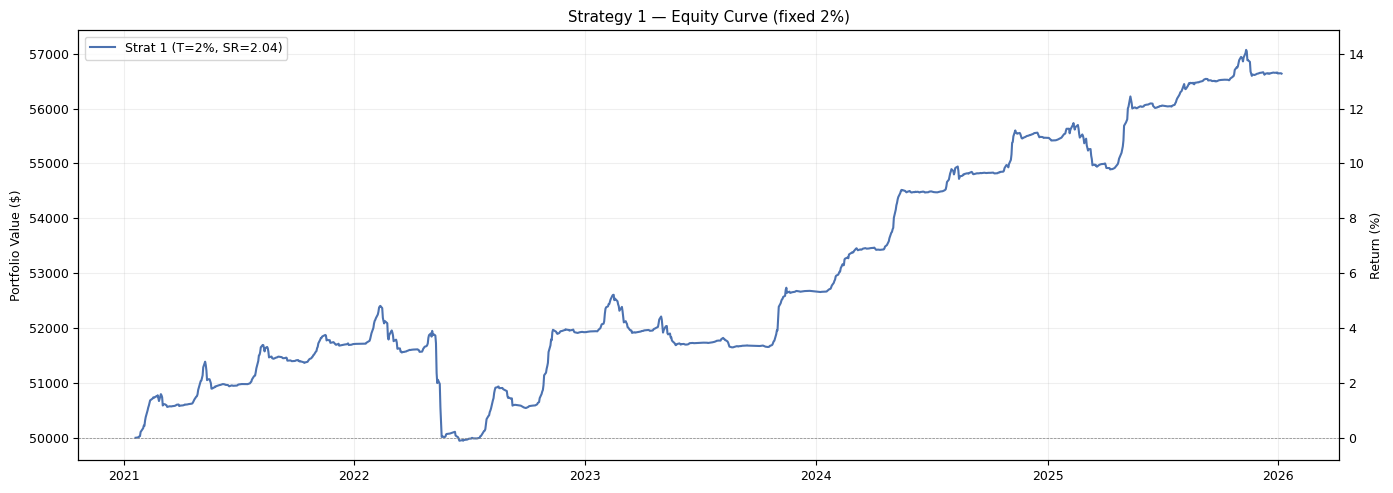

In [188]:
# Strat 1 — equity curve (fixed 2%)
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates_s1, equity_s1, lw=1.5, color='#4C72B0', label=f'Strat 1 (T=2%, SR={sr_s1:.2f})')
ax.axhline(INITIAL_CAPITAL, color='gray', lw=0.5, ls='--')
ax.set_title("Strategy 1 — Equity Curve (fixed 2%)")
ax.set_ylabel("Portfolio Value ($)")
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
axb = ax.twinx()
y0, y1 = ax.get_ylim()
axb.set_ylim(100*(y0/INITIAL_CAPITAL-1), 100*(y1/INITIAL_CAPITAL-1))
axb.set_ylabel("Return (%)")
plt.tight_layout()
plt.show()


---
## 4. Strategy 2 — Threshold Sweep (1%–5%)


In [189]:
def compute_strat1_pnl(threshold):
    """Per-trade P&L + sell date at a single take-profit threshold."""
    crossed = cummax_rets > threshold
    first_idx = np.argmax(crossed, axis=1)
    did_cross = crossed[np.arange(N), first_idx]
    pnl = np.where(did_cross, threshold, close_t10_ret) * POSITION_SIZE
    sell_date = np.where(did_cross, drift_dates[np.arange(N), first_idx], close_t10_date)
    return pnl, sell_date


def filter_by_cash(pnl, sell_date, entry_date, initial_cap, pos_size):
    """Simulate entries+exits chronologically. Skips buys if cash < pos_size."""
    n = len(pnl)
    events = []
    for i in range(n):
        events.append((entry_date[i], "enter", i))
        events.append((sell_date[i], "exit", i))
    events.sort(key=lambda x: x[0])
    cash = initial_cap
    skipped = 0
    entered = set()
    for dt, etype, idx in events:
        if etype == "exit":
            if idx in entered:
                cash += pos_size + pnl[idx]  # return capital + P&L
        else:
            if cash >= pos_size:
                cash -= pos_size
                entered.add(idx)
            else:
                skipped += 1
    keep = np.sort(list(entered))
    return pnl[keep], sell_date[keep], entry_date[keep], skipped


def build_daily_equity(pnl, sell_date, initial_cap, entry_date=None, pos_size=None):
    """Aggregate P&L by sell date, build dollar-additive equity curve.
    Returns (dates, daily_rets, equity, deployed_mean, daily_rets_deployed).
    - daily_rets = pnl_vals / prev_equity  (portfolio-level, used for equity curve + Sharpe)
    - daily_rets_deployed = pnl_vals / deployed  (invariant to INITIAL_CAPITAL, used for RoDC)
    """
    dates_py = sell_date.tolist()
    daily_pnl = pl.DataFrame({"sell_date": pl.Series(dates_py, dtype=pl.Date), "pnl": pnl})
    daily_pnl = daily_pnl.group_by("sell_date").agg(pl.sum("pnl")).sort("sell_date")
    dates = daily_pnl["sell_date"].to_numpy()
    pnl_vals = daily_pnl["pnl"].to_numpy()

    # Dollar-additive equity
    cum_pnl = np.cumsum(pnl_vals)
    equity = initial_cap + cum_pnl

    # Portfolio-level daily returns (pnl / previous-day equity)
    prev_equity = np.concatenate([[initial_cap], equity[:-1]])
    prev_equity = np.maximum(prev_equity, 1.0)
    daily_rets = pnl_vals / prev_equity

    # Deployed capital and returns on capital at risk
    if entry_date is not None and pos_size is not None:
        events = []
        for i in range(len(pnl)):
            events.append((entry_date[i], "enter"))
            events.append((sell_date[i], "exit"))
        events.sort(key=lambda x: x[0])
        depl_lookup = {}
        running = 0
        for dt, etype in events:
            if etype == "enter":
                running += pos_size
            else:
                if dt not in depl_lookup:
                    depl_lookup[dt] = max(running, pos_size)
                running -= pos_size
        deployed = np.array([depl_lookup.get(d, pos_size) for d in dates])
        deployed = np.maximum(deployed, pos_size)
    else:
        deployed = np.full_like(pnl_vals, initial_cap, dtype=float)

    daily_rets_deployed = pnl_vals / deployed

    # Cumulative RoDC: cum_pnl / cummean(deployed) — endpoint = final RoDC
    cmean_deployed = np.cumsum(deployed) / np.arange(1, len(deployed) + 1)
    rodc_cum = cum_pnl / cmean_deployed

    print(f"    [debug] depl: min=${deployed.min():.0f}"
          f" mean=${deployed.mean():.0f}"
          f" max=${deployed.max():.0f} |"
          f" ret_std_portfolio={daily_rets.std():.4f}"
          f" ret_std_deployed={daily_rets_deployed.std():.4f} |"
          f" PnL=${cum_pnl[-1]:.0f}"
          f" eq=${equity[-1]:.0f}"
          f" RoDC_end=${rodc_cum[-1]:.1%}")

    return dates, daily_rets, equity, deployed.mean(), daily_rets_deployed, rodc_cum



def sharpe_annualised(daily_rets):
    if daily_rets.std() == 0:
        return 0.0
    return float(daily_rets.mean() / daily_rets.std() * np.sqrt(252))


# ── Run threshold sweep ───────────────────────────────────────────────
results_s1 = []
for T in THRESHOLDS:
    pnl, sell_date = compute_strat1_pnl(T)
    pnl, sell_date, entry_f, n_skipped = filter_by_cash(pnl, sell_date, entry_dates, INITIAL_CAPITAL, POSITION_SIZE)
    dates, daily_rets, equity, depl_mean, dr_deployed, rodc_cum = build_daily_equity(pnl, sell_date, INITIAL_CAPITAL, entry_f, POSITION_SIZE)
    sr = sharpe_annualised(daily_rets)
    sr_depl = sharpe_annualised(dr_deployed)
    total_pnl = pnl.sum()
    win_rate = (pnl > 0).mean()
    results_s1.append({
        "threshold": T, "sharpe": sr, "total_pnl": total_pnl,
        "win_rate": win_rate, "equity": equity, "dates": dates,
            "n_trades": len(pnl),
        "daily_rets": daily_rets, "n_skipped": n_skipped,
                "depl_mean": depl_mean, "rodc_cum": rodc_cum,
    })
    print(f"  T={T:4.1%}  SR={sr:5.2f}  SRd={sr_depl:5.2f}  P&L=${total_pnl:>8,.0f}  Win={win_rate:5.1%}  Sk={n_skipped}  EqEnd=${equity[-1]:,.0f}  RoDC={total_pnl/depl_mean:.1%}  RoAA={total_pnl/INITIAL_CAPITAL:.1%}")

    [debug] depl: min=$200 mean=$4913 max=$30000 | ret_std_portfolio=0.0007 ret_std_deployed=0.0096 | PnL=$2868 eq=$52868 RoDC_end=$58.4%
  T=1.0%  SR= 1.27  SRd=-0.51  P&L=$   2,868  Win=86.2%  Sk=0  EqEnd=$52,868  RoDC=58.4%  RoAA=5.7%
    [debug] depl: min=$200 mean=$6147 max=$33200 | ret_std_portfolio=0.0009 ret_std_deployed=0.0097 | PnL=$4921 eq=$54921 RoDC_end=$80.1%
  T=1.5%  SR= 1.75  SRd=-0.45  P&L=$   4,921  Win=80.6%  Sk=0  EqEnd=$54,921  RoDC=80.1%  RoAA=9.8%
    [debug] depl: min=$200 mean=$7257 max=$36800 | ret_std_portfolio=0.0010 ret_std_deployed=0.0096 | PnL=$6637 eq=$56637 RoDC_end=$91.5%
  T=2.0%  SR= 2.04  SRd=-0.01  P&L=$   6,637  Win=75.9%  Sk=0  EqEnd=$56,637  RoDC=91.5%  RoAA=13.3%
    [debug] depl: min=$200 mean=$8426 max=$40000 | ret_std_portfolio=0.0011 ret_std_deployed=0.0094 | PnL=$7903 eq=$57903 RoDC_end=$93.8%
  T=2.5%  SR= 2.19  SRd= 0.30  P&L=$   7,903  Win=71.5%  Sk=0  EqEnd=$57,903  RoDC=93.8%  RoAA=15.8%
    [debug] depl: min=$200 mean=$9360 max=$452

In [190]:
# target_return_actual from results vs cummax of drift_highs
max_from_drift = cummax_rets[:, -1]  # max across all 9 days
actual_from_results = signals["target_return_actual"].to_numpy()

diff = np.abs(max_from_drift - actual_from_results)
print(f"Max difference: {diff.max():.6f}")
print(f"Mismatched rows: {(diff > 0.001).sum()}")

Max difference: 0.000000
Mismatched rows: 0


In [191]:
# What fraction of trades actually exceed 18%?
print(f"Fraction > 18%: {(signals['target_return_actual'] > 0.18).mean():.2%}")

Fraction > 18%: 1.95%


In [192]:
# ── Select best threshold by Sharpe ───────────────────────────────────
best_idx = max(range(len(results_s1)), key=lambda i: results_s1[i]["sharpe"])
best = results_s1[best_idx]
BEST_T = best["threshold"]
print(f"\nBest threshold: {BEST_T:.1%}  (Sharpe: {best['sharpe']:.2f}, "
      f"P&L: ${best['total_pnl']:,.0f}, Skipped: {best['n_skipped']})")


Best threshold: 5.0%  (Sharpe: 2.33, P&L: $12,138, Skipped: 13)


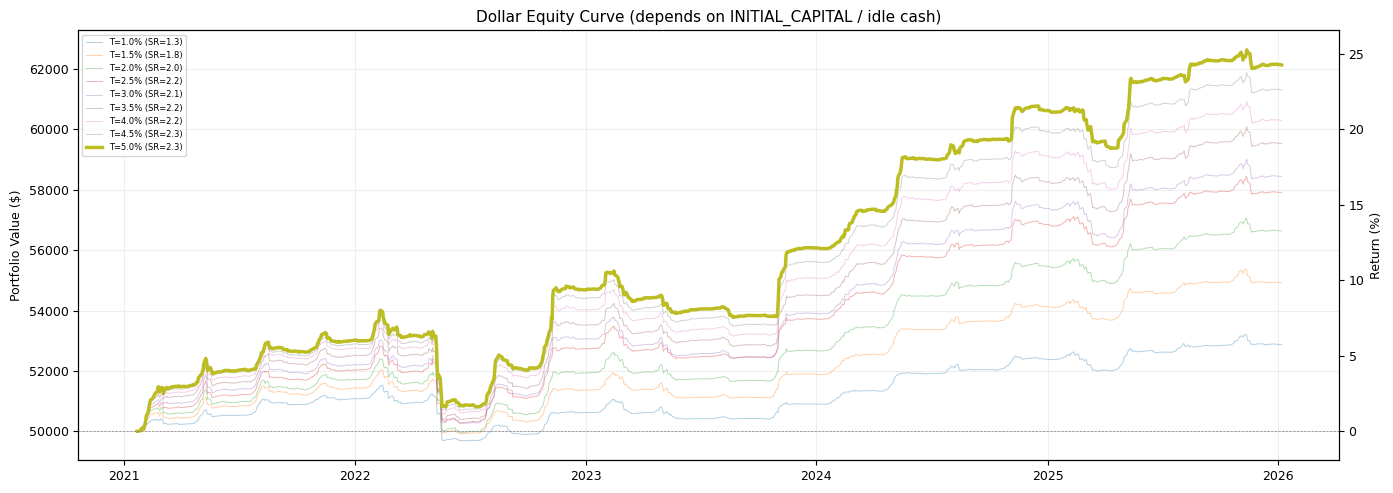

In [193]:
# Strat 2 — Dollar Equity Curves by Threshold
fig, ax = plt.subplots(figsize=(14, 5))

for r in results_s1:
    label = f"T={r['threshold']:.1%} (SR={r['sharpe']:.1f})"
    lw = 2.5 if r["threshold"] == BEST_T else 0.7
    alpha = 1.0 if r["threshold"] == BEST_T else 0.35
    ax.plot(r["dates"], r["equity"], label=label, lw=lw, alpha=alpha)

ax.axhline(INITIAL_CAPITAL, color="gray", lw=0.5, ls="--")
ax.set_title("Dollar Equity Curve (depends on INITIAL_CAPITAL / idle cash)", fontsize=11)
ax.set_ylabel("Portfolio Value ($)")
ax.legend(fontsize=6, loc="upper left")
ax.grid(alpha=0.2)
axb = ax.twinx()
y0, y1 = ax.get_ylim()
axb.set_ylim(100*(y0/INITIAL_CAPITAL-1), 100*(y1/INITIAL_CAPITAL-1))
axb.set_ylabel("Return (%)")

plt.tight_layout()
plt.show()


In [194]:
# ── Helper: deployed capital per trade ───────────────────────────────
def compute_deployed(pnl_arr, sell_arr, entry_arr, pos):
    events = []
    for i in range(len(pnl_arr)):
        events.append((entry_arr[i], "enter"))
        events.append((sell_arr[i], "exit"))
    events.sort(key=lambda x: x[0])
    depl = {}
    running = 0
    for dt, etype in events:
        if etype == "enter":
            running += pos
        else:
            if dt not in depl:
                depl[dt] = max(running, pos)
            running -= pos
    return np.array([depl.get(d, pos) for d in sell_arr])


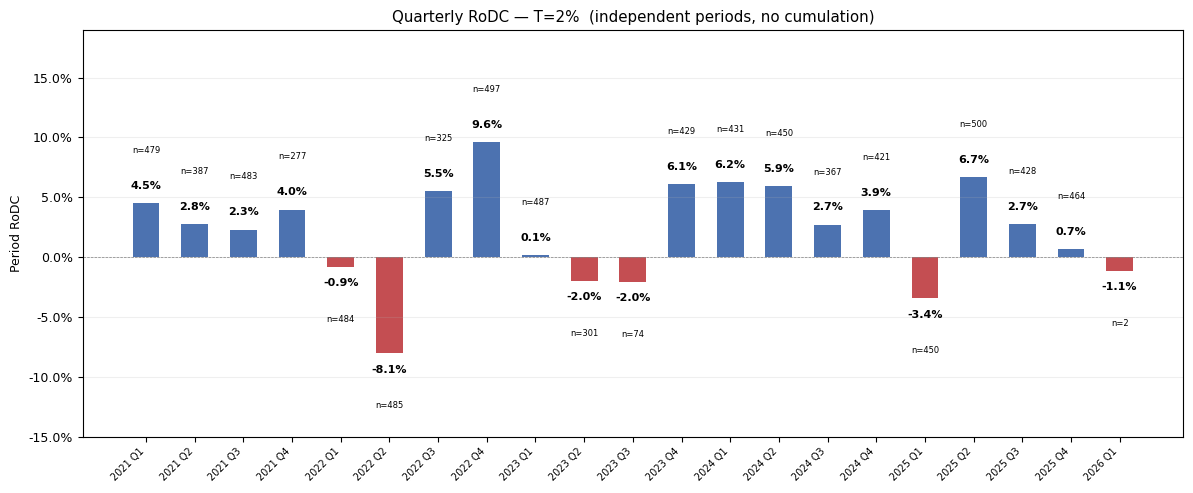

In [195]:
# ── Quarterly RoDC — T=2% (independent periods, no cumulation) ──
T = 0.02

pnl_p, sell_p = compute_strat1_pnl(T)
pnl_p, sell_p, entry_p, sk = filter_by_cash(pnl_p, sell_p, entry_dates, INITIAL_CAPITAL, POSITION_SIZE)
deployed_p = compute_deployed(pnl_p, sell_p, entry_p, POSITION_SIZE)

qdf = pl.DataFrame({
    "sell_date": pl.Series(sell_p.tolist(), dtype=pl.Date),
    "pnl": pnl_p,
    "deployed": deployed_p,
}).with_columns([
    pl.col("sell_date").dt.year().alias("year"),
    pl.col("sell_date").dt.quarter().alias("quarter"),
    (pl.col("sell_date").dt.year().cast(pl.Utf8) + " Q" + pl.col("sell_date").dt.quarter().cast(pl.Utf8)).alias("period"),
])

qt = qdf.group_by("year", "quarter", "period").agg([
    pl.sum("pnl").alias("period_pnl"),
    pl.mean("deployed").alias("mean_deployed"),
    pl.len().alias("n_trades"),
]).sort("year", "quarter").with_columns([
    (pl.col("period_pnl") / pl.col("mean_deployed")).alias("rodc"),
])

periods = qt["period"].to_list()
rodc_vals = qt["rodc"].to_list()
n_vals = qt["n_trades"].to_list()

# Padding so bar labels stay inside the figure
y_min = min(rodc_vals) if rodc_vals else 0
y_max = max(rodc_vals) if rodc_vals else 0
y_lo = min(y_min * 1.4, -0.15)
y_hi = y_max * 1.35 + 0.06

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#4C72B0" if v >= 0 else "#C44E52" for v in rodc_vals]
ax.bar(range(len(periods)), rodc_vals, color=colors, width=0.55)
ax.axhline(0, color="gray", lw=0.5, ls="--")
ax.set_ylim(y_lo, y_hi)
ax.set_title(f"Quarterly RoDC — T=2%  (independent periods, no cumulation)")
ax.set_ylabel("Period RoDC")
ax.set_xticks(range(len(periods)))
ax.set_xticklabels(periods, fontsize=7, rotation=45, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax.grid(alpha=0.2, axis="y")
for i, v in enumerate(rodc_vals):
    yoff = 0.012 if v >= 0 else -0.016
    ax.text(i, v + yoff, f"{v:.1%}", ha="center", fontsize=8,
            fontweight="bold", color="black")
    ax.text(i, v + yoff + (0.03 if v >= 0 else -0.03), f"n={n_vals[i]}", ha="center",
            fontsize=6, color="black")

plt.tight_layout()
plt.show()


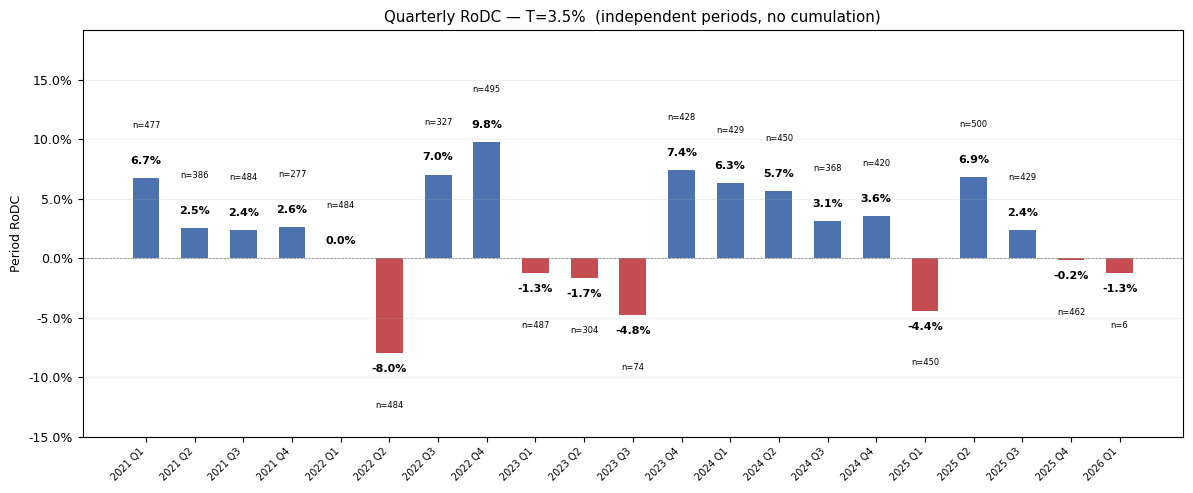

In [196]:
# ── Quarterly RoDC — T=3.5% (independent periods, no cumulation) ──
T = 0.035

pnl_p, sell_p = compute_strat1_pnl(T)
pnl_p, sell_p, entry_p, sk = filter_by_cash(pnl_p, sell_p, entry_dates, INITIAL_CAPITAL, POSITION_SIZE)
deployed_p = compute_deployed(pnl_p, sell_p, entry_p, POSITION_SIZE)

qdf = pl.DataFrame({
    "sell_date": pl.Series(sell_p.tolist(), dtype=pl.Date),
    "pnl": pnl_p,
    "deployed": deployed_p,
}).with_columns([
    pl.col("sell_date").dt.year().alias("year"),
    pl.col("sell_date").dt.quarter().alias("quarter"),
    (pl.col("sell_date").dt.year().cast(pl.Utf8) + " Q" + pl.col("sell_date").dt.quarter().cast(pl.Utf8)).alias("period"),
])

qt = qdf.group_by("year", "quarter", "period").agg([
    pl.sum("pnl").alias("period_pnl"),
    pl.mean("deployed").alias("mean_deployed"),
    pl.len().alias("n_trades"),
]).sort("year", "quarter").with_columns([
    (pl.col("period_pnl") / pl.col("mean_deployed")).alias("rodc"),
])

periods = qt["period"].to_list()
rodc_vals = qt["rodc"].to_list()
n_vals = qt["n_trades"].to_list()

# Padding so bar labels stay inside the figure
y_min = min(rodc_vals) if rodc_vals else 0
y_max = max(rodc_vals) if rodc_vals else 0
y_lo = min(y_min * 1.4, -0.15)
y_hi = y_max * 1.35 + 0.06

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#4C72B0" if v >= 0 else "#C44E52" for v in rodc_vals]
ax.bar(range(len(periods)), rodc_vals, color=colors, width=0.55)
ax.axhline(0, color="gray", lw=0.5, ls="--")
ax.set_ylim(y_lo, y_hi)
ax.set_title(f"Quarterly RoDC — T=3.5%  (independent periods, no cumulation)")
ax.set_ylabel("Period RoDC")
ax.set_xticks(range(len(periods)))
ax.set_xticklabels(periods, fontsize=7, rotation=45, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax.grid(alpha=0.2, axis="y")
for i, v in enumerate(rodc_vals):
    yoff = 0.012 if v >= 0 else -0.016
    ax.text(i, v + yoff, f"{v:.1%}", ha="center", fontsize=8,
            fontweight="bold", color="black")
    ax.text(i, v + yoff + (0.03 if v >= 0 else -0.03), f"n={n_vals[i]}", ha="center",
            fontsize=6, color="black")

plt.tight_layout()
plt.show()


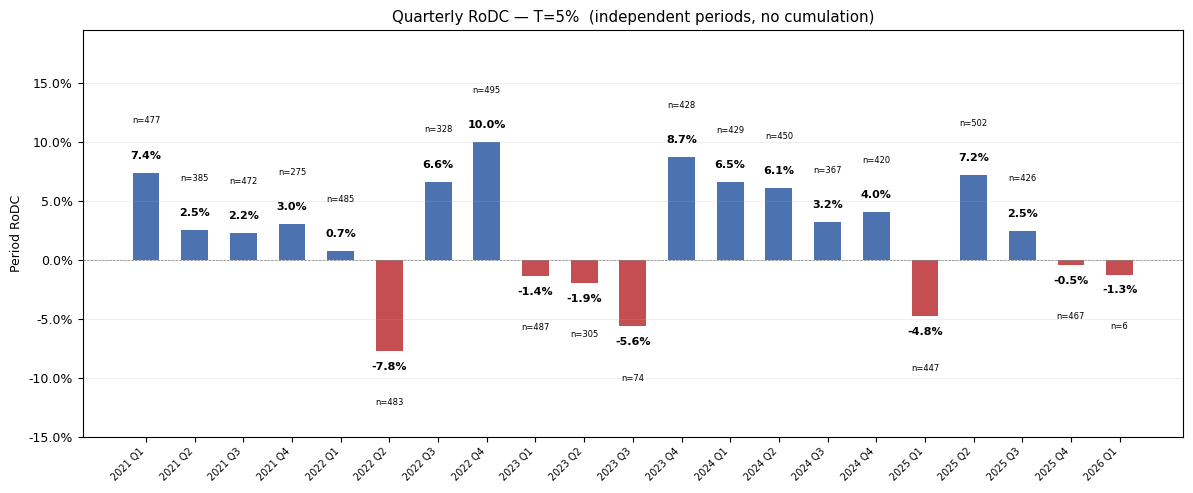

In [197]:
# ── Quarterly RoDC — T=5% (independent periods, no cumulation) ──
T = 0.05

pnl_p, sell_p = compute_strat1_pnl(T)
pnl_p, sell_p, entry_p, sk = filter_by_cash(pnl_p, sell_p, entry_dates, INITIAL_CAPITAL, POSITION_SIZE)
deployed_p = compute_deployed(pnl_p, sell_p, entry_p, POSITION_SIZE)

qdf = pl.DataFrame({
    "sell_date": pl.Series(sell_p.tolist(), dtype=pl.Date),
    "pnl": pnl_p,
    "deployed": deployed_p,
}).with_columns([
    pl.col("sell_date").dt.year().alias("year"),
    pl.col("sell_date").dt.quarter().alias("quarter"),
    (pl.col("sell_date").dt.year().cast(pl.Utf8) + " Q" + pl.col("sell_date").dt.quarter().cast(pl.Utf8)).alias("period"),
])

qt = qdf.group_by("year", "quarter", "period").agg([
    pl.sum("pnl").alias("period_pnl"),
    pl.mean("deployed").alias("mean_deployed"),
    pl.len().alias("n_trades"),
]).sort("year", "quarter").with_columns([
    (pl.col("period_pnl") / pl.col("mean_deployed")).alias("rodc"),
])

periods = qt["period"].to_list()
rodc_vals = qt["rodc"].to_list()
n_vals = qt["n_trades"].to_list()

# Padding so bar labels stay inside the figure
y_min = min(rodc_vals) if rodc_vals else 0
y_max = max(rodc_vals) if rodc_vals else 0
y_lo = min(y_min * 1.4, -0.15)
y_hi = y_max * 1.35 + 0.06

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#4C72B0" if v >= 0 else "#C44E52" for v in rodc_vals]
ax.bar(range(len(periods)), rodc_vals, color=colors, width=0.55)
ax.axhline(0, color="gray", lw=0.5, ls="--")
ax.set_ylim(y_lo, y_hi)
ax.set_title(f"Quarterly RoDC — T=5%  (independent periods, no cumulation)")
ax.set_ylabel("Period RoDC")
ax.set_xticks(range(len(periods)))
ax.set_xticklabels(periods, fontsize=7, rotation=45, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax.grid(alpha=0.2, axis="y")
for i, v in enumerate(rodc_vals):
    yoff = 0.012 if v >= 0 else -0.016
    ax.text(i, v + yoff, f"{v:.1%}", ha="center", fontsize=8,
            fontweight="bold", color="black")
    ax.text(i, v + yoff + (0.03 if v >= 0 else -0.03), f"n={n_vals[i]}", ha="center",
            fontsize=6, color="black")

plt.tight_layout()
plt.show()


In [198]:
# ── Yearly RoDC table — independent periods per year, no cumulation ──
print()
print("=" * 65)
print("Yearly Return on Deployed Capital — independent periods (no cumulation between years)")
print("=" * 65)
header = f"{'Year':<8}"
for T in REP_THRESHOLDS:
    header += f" {'T=' + str(int(T*100)) + '%':>17}"
print(header)
print("        " + "-" * (len(REP_THRESHOLDS) * 18))

yearly_data = {}
for T in REP_THRESHOLDS:
    pnl_t, sell_t = compute_strat1_pnl(T)
    pnl_t, sell_t, entry_t, sk = filter_by_cash(pnl_t, sell_t, entry_dates, INITIAL_CAPITAL, POSITION_SIZE)
    deployed_t = compute_deployed(pnl_t, sell_t, entry_t, POSITION_SIZE)

    ydf = pl.DataFrame({
        "sell_date": pl.Series(sell_t.tolist(), dtype=pl.Date),
        "pnl": pnl_t,
        "deployed": deployed_t,
    }).with_columns([
        pl.col("sell_date").dt.year().alias("year"),
    ])

    yt = ydf.group_by("year").agg([
        pl.sum("pnl").alias("total_pnl"),
        pl.mean("deployed").alias("mean_deployed"),
        pl.len().alias("trades"),
    ]).sort("year").with_columns([
        (pl.col("total_pnl") / pl.col("mean_deployed")).alias("rodc"),
    ])

    for row in yt.iter_rows():
        yr, pnl_v, depl_v, n, rodc = row
        if yr not in yearly_data:
            yearly_data[yr] = {}
        yearly_data[yr][T] = (rodc, n)

years = sorted(yearly_data.keys())
for yr in years:
    row_str = f"{yr:<8}"
    for T in REP_THRESHOLDS:
        if T in yearly_data[yr]:
            rodc, n = yearly_data[yr][T]
            row_str += f" {rodc:>8.1%} (n={n:>4})"
        else:
            row_str += f" {'—':>8} {'':>7}"
    print(row_str)
print()



Yearly Return on Deployed Capital — independent periods (no cumulation between years)
Year                  T=2%              T=3%              T=5%
        ------------------------------------------------------
2021        12.1% (n=1626)    13.2% (n=1624)    14.0% (n=1609)
2022         1.5% (n=1791)     4.9% (n=1790)     7.0% (n=1791)
2023         5.5% (n=1291)     5.4% (n=1293)     6.6% (n=1294)
2024        18.9% (n=1669)    18.7% (n=1667)    19.9% (n=1666)
2025         7.2% (n=1842)     5.7% (n=1841)     5.9% (n=1842)
2026        -1.1% (n=   2)    -1.3% (n=   6)    -1.3% (n=   6)



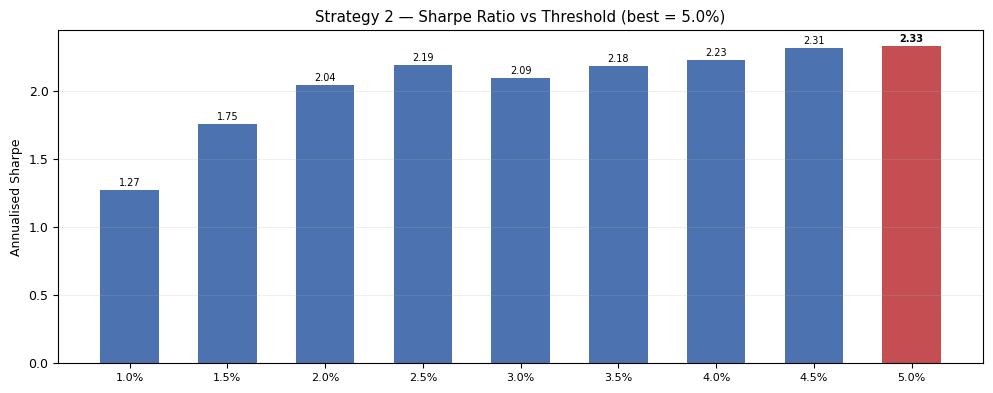

In [199]:
# Strat 2 — Sharpe vs Threshold bar chart
fig2, ax2 = plt.subplots(figsize=(10, 4))
T_list = [r["threshold"] for r in results_s1]
sr_list = [r["sharpe"] for r in results_s1]
pnl_list = [r["total_pnl"] for r in results_s1]
colors = ["#4C72B0" if i != best_idx else "#C44E52" for i in range(len(results_s1))]
ax2.bar(range(len(T_list)), sr_list, color=colors, width=0.6)
ax2.set_xticks(range(len(T_list)))
ax2.set_xticklabels([f"{t:.1%}" for t in T_list], fontsize=8)
ax2.set_title(f"Strategy 2 — Sharpe Ratio vs Threshold (best = {BEST_T:.1%})")
ax2.set_ylabel("Annualised Sharpe")
ax2.grid(alpha=0.2, axis="y")
for i, sr in enumerate(sr_list):
    ax2.text(i, sr + 0.03, f"{sr:.2f}", ha="center", fontsize=7,
             fontweight="bold" if i == best_idx else "normal")
plt.tight_layout()
plt.show()


---
## 3b. Yearly & Quarterly Summary (Best Threshold)


In [200]:
# Build per-trade DataFrame for the best threshold
pnl_best, sell_date_best = compute_strat1_pnl(BEST_T)
pnl_best, sell_date_best, entry_best, _ = filter_by_cash(pnl_best, sell_date_best, entry_dates, INITIAL_CAPITAL, POSITION_SIZE)

trades_best = pl.DataFrame({
    "sell_date": sell_date_best.tolist(),
    "pnl": pnl_best,
}).with_columns(
    pl.col("sell_date").cast(pl.Date),
    pl.col("sell_date").dt.year().alias("year"),
    pl.col("sell_date").dt.quarter().alias("quarter"),
    (pl.col("pnl") > 0).alias("is_win"),
)

# Yearly summary
yearly = trades_best.group_by("year").agg([
    pl.len().alias("trades"),
    pl.sum("pnl").alias("total_pnl"),
    pl.mean("pnl").alias("avg_pnl"),
    pl.mean("is_win").alias("win_rate"),
]).sort("year")

print("Year  Trades    P&L ($)   Avg P&L  Win Rate")
print("-" * 48)
for row in yearly.iter_rows():
    yr, n, pnl_val, avg, wr = row
    print(f"{yr:<6} {n:>5} {pnl_val:>+10,.0f} {avg:>+9.2f} {wr:>9.1%}")

# Quarterly summary
quarterly = trades_best.group_by(["year", "quarter"]).agg([
    pl.len().alias("trades"),
    pl.sum("pnl").alias("total_pnl"),
    pl.mean("pnl").alias("avg_pnl"),
    pl.mean("is_win").alias("win_rate"),
]).sort(["year", "quarter"])

quarterly = quarterly.with_columns(
    (pl.col("year").cast(pl.Utf8) + " Q" + pl.col("quarter").cast(pl.Utf8)).alias("label"),
    pl.col("total_pnl").cum_sum().alias("cum_pnl"),
)

print("\nQuarter   Trades     P&L ($)  Cum P&L   Avg P&L  Win Rate")
print("-" * 64)
for row in quarterly.iter_rows():
    yr, q, n, pnl_val, avg, wr, label, cum = row
    print(f"{label:<10} {n:>5} {pnl_val:>+10,.0f} {cum:>+10,.0f} {avg:>+9.2f} {wr:>9.1%}")

Year  Trades    P&L ($)   Avg P&L  Win Rate
------------------------------------------------
2021    1609     +3,018     +1.88     61.7%
2022    1791     +1,662     +0.93     60.4%
2023    1294     +1,393     +1.08     56.6%
2024    1666     +4,552     +2.73     66.1%
2025    1842     +1,525     +0.83     58.3%
2026       6        -11     -1.89     33.3%

Quarter   Trades     P&L ($)  Cum P&L   Avg P&L  Win Rate
----------------------------------------------------------------
2021 Q1      477     +1,481     +1,481     +3.10     68.8%
2021 Q2      385       +527     +2,008     +1.37     57.7%
2021 Q3      472       +645     +2,654     +1.37     59.7%
2021 Q4      275       +364     +3,018     +1.32     58.2%
2022 Q1      485       +140     +3,158     +0.29     56.3%
2022 Q2      483     -2,292       +866     -4.75     36.2%
2022 Q3      328     +1,159     +2,025     +3.53     74.1%
2022 Q4      495     +2,655     +4,679     +5.36     78.8%
2023 Q1      487       -298     +4,381     -0.6

---
## 5. Strategy 3 — Split-Sell Exit

Using best T from Strat 2. Sell a fraction at (split_pct × T),
remainder at full T (or t+10 if never hit). Tests 70/30, 60/40, 50/50.


In [201]:
# Split-sell: sell frac at (frac * BEST_T), rest at BEST_T or t+10
SPLIT_RATIOS = [0.7, 0.6, 0.5]

full_crossed = cummax_rets > BEST_T
f_idx = np.argmax(full_crossed, axis=1)
f_did = full_crossed[np.arange(N), f_idx]

strat3_results = []
for frac in SPLIT_RATIOS:
    partial_T = BEST_T * frac
    amt_first = POSITION_SIZE * frac
    amt_rest = POSITION_SIZE - amt_first

    pcrossed = cummax_rets > partial_T
    p_idx = np.argmax(pcrossed, axis=1)
    p_did = pcrossed[np.arange(N), p_idx]

    pnl_list2, sell_list2, entry_list2 = [], [], []
    for i in range(N):
        if p_did[i]:
            entry_list2.append(entry_dates[i])
            pnl_list2.append(amt_first * partial_T)
            sell_list2.append(drift_dates[i, p_idx[i]])
            if f_did[i]:
                entry_list2.append(entry_dates[i])
                pnl_list2.append(amt_rest * BEST_T)
                sell_list2.append(drift_dates[i, f_idx[i]])
            else:
                entry_list2.append(entry_dates[i])
                pnl_list2.append(amt_rest * close_t10_ret[i])
                sell_list2.append(close_t10_date[i])
        else:
            entry_list2.append(entry_dates[i])
            pnl_list2.append(POSITION_SIZE * close_t10_ret[i])
            sell_list2.append(close_t10_date[i])

    pnl_arr = np.array(pnl_list2)
    sell_arr = np.array(sell_list2)
    entry_arr = np.array(entry_list2)

    pnl_arr, sell_arr, entry_arr, skipped = filter_by_cash(pnl_arr, sell_arr, entry_arr, INITIAL_CAPITAL, amt_first)
    dates, daily_rets, equity, depl_mean, dr_deployed, rodc_cum = build_daily_equity(pnl_arr, sell_arr, INITIAL_CAPITAL, entry_arr, amt_first)
    sr = sharpe_annualised(daily_rets)
    sr_depl = sharpe_annualised(dr_deployed)

    lbl = f"{int(frac*100)}/{int((1-frac)*100)}"
    strat3_results.append(dict(split=lbl, frac=frac, sharpe=sr, total_pnl=pnl_arr.sum(),
        win_rate=(pnl_arr>0).mean(), equity=equity, dates=dates, n_exits=len(pnl_arr), skipped=skipped))
    print(f"  Split {lbl}: SR={sr:.2f}  SRd={sr_depl:.2f}  PnL=${pnl_arr.sum():,.0f}  Win={(pnl_arr>0).mean():.1%}  EqEnd=${equity[-1]:,.0f}  RoDC={pnl_arr.sum()/depl_mean:.1%}  RoAA={pnl_arr.sum()/INITIAL_CAPITAL:.1%}")


    [debug] depl: min=$140 mean=$10152 max=$52780 | ret_std_portfolio=0.0013 ret_std_deployed=0.0098 | PnL=$10251 eq=$60251 RoDC_end=$101.0%
  Split 70/30: SR=2.18  SRd=-0.71  PnL=$10,251  Win=74.3%  EqEnd=$60,251  RoDC=101.0%  RoAA=20.5%
    [debug] depl: min=$120 mean=$8570 max=$46080 | ret_std_portfolio=0.0013 ret_std_deployed=0.0111 | PnL=$9904 eq=$59904 RoDC_end=$115.6%
  Split 60/40: SR=2.16  SRd=-0.74  PnL=$9,904  Win=75.2%  EqEnd=$59,904  RoDC=115.6%  RoAA=19.8%
    [debug] depl: min=$100 mean=$7076 max=$37900 | ret_std_portfolio=0.0012 ret_std_deployed=0.0129 | PnL=$10004 eq=$60004 RoDC_end=$141.4%
  Split 50/50: SR=2.23  SRd=-0.51  PnL=$10,004  Win=76.3%  EqEnd=$60,004  RoDC=141.4%  RoAA=20.0%


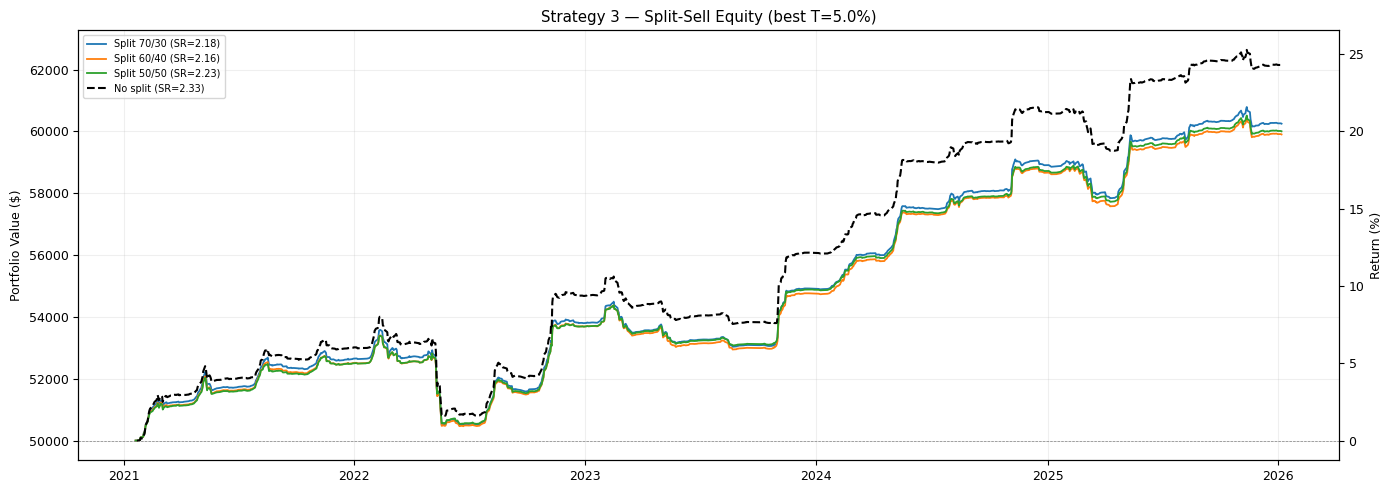

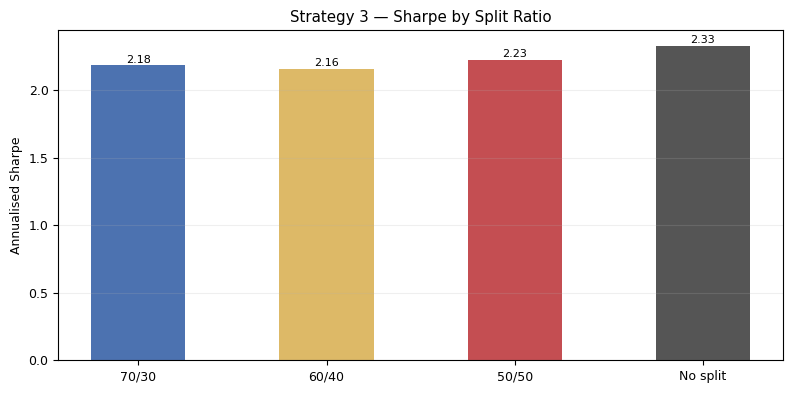

In [202]:
# Strat 3 — Equity curves overlay by split ratio
fig1, ax1 = plt.subplots(figsize=(14, 5))
for r in strat3_results:
    ax1.plot(r["dates"], r["equity"], lw=1.3, label=f"Split {r["split"]} (SR={r["sharpe"]:.2f})")
ax1.plot(best["dates"], best["equity"], "k--", lw=1.5, label=f"No split (SR={best["sharpe"]:.2f})")
ax1.axhline(INITIAL_CAPITAL, color="gray", lw=0.5, ls="--")
ax1.set_title(f"Strategy 3 — Split-Sell Equity (best T={BEST_T:.1%})")
ax1.set_ylabel("Portfolio Value ($)")
ax1.legend(fontsize=7)
ax1.grid(alpha=0.2)
ax1b = ax1.twinx()
y0, y1 = ax1.get_ylim()
ax1b.set_ylim(100*(y0/INITIAL_CAPITAL-1), 100*(y1/INITIAL_CAPITAL-1))
ax1b.set_ylabel("Return (%)")
plt.tight_layout()
plt.show()

# Strat 3 — Sharpe by split ratio + No split comparison
fig2, ax2 = plt.subplots(figsize=(8, 4))
labels = [r["split"] for r in strat3_results] + ["No split"]
sr_vals = [r["sharpe"] for r in strat3_results] + [best["sharpe"]]
colors = ["#4C72B0", "#DDB967", "#C44E52", "#555555"]
ax2.bar(range(len(labels)), sr_vals, color=colors, width=0.5)
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels)
ax2.set_title("Strategy 3 — Sharpe by Split Ratio")
ax2.set_ylabel("Annualised Sharpe")
ax2.grid(alpha=0.2, axis="y")
for i, sr in enumerate(sr_vals):
    ax2.text(i, sr + 0.02, f"{sr:.2f}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()


---
## Notes

- **Equity** is dollar-additive: `initial_cap + cumsum(daily P&L)`. Inactive days hold flat.
- **SR**  = annualised Sharpe from `daily_rets = pnl / prev_equity` (portfolio-level, depends on INITIAL_CAPITAL).
- **SRd** = annualised Sharpe from `daily_rets_deployed = pnl / deployed` (invariant to INITIAL_CAPITAL).
- **RoDC** = total P&L / mean deployed capital (return on capital at risk, invariant).
- **RoAA** = total P&L / INITIAL_CAPITAL (return on full account, depends on INITIAL_CAPITAL).
- **Cash filter**: Trades are processed in entry-date order. If cash drops below
  `POSITION_SIZE`, subsequent trades are skipped (counted in `Sk` column).
  With $100/position and $50K capital, zero trades skip (max ~500 concurrent).
- **Sell dates** are exact — `date_t+{offset}` columns from daily OHLCV give
  actual calendar sell dates at the crossing day.
- **% Return**: right axis is scaled to match the dollar axis — 0% = $50K,
  10% = $55K, etc.
- **No slippage or commissions** are modeled. Add ~5-10 bps per trade for realism.